<a href="https://colab.research.google.com/github/F-Abir/GEE-Python-API/blob/main/Precipation_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import ee

In [3]:
import geemap

In [4]:
import xarray as xr

In [5]:
!pip install xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.1 MB/s eta 0:00:00


In [7]:
import xee

In [8]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-abirnahraf',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [9]:
roi  = ee.FeatureCollection("UN/Geodata/BNDA_simplified/current").filter(ee.Filter.stringContains('nam_en', 'Bangladesh')).geometry()

In [10]:
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Collection.geometry",
    "arguments": {
      "collection": {
        "functionInvocationValue": {
          "functionName": "Collection.filter",
          "arguments": {
            "collection": {
              "functionInvocationValue": {
                "functionName": "Collection.loadTable",
                "arguments": {
                  "tableId": {
                    "constantValue": "UN/Geodata/BNDA_simplified/current"
                  }
                }
              }
            },
            "filter": {
              "functionInvocationValue": {
                "functionName": "Filter.stringContains",
                "arguments": {
                  "leftField": {
                    "constantValue": "nam_en"
                  },
                  "rightValue": {
                    "constantValue": "Bangladesh"
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [11]:
map = geemap.Map(basemap = 'SATELLITE')

In [13]:
map.centerObject(roi, 5)

In [14]:
map.addLayer(roi, {}, 'roi')

In [17]:
pr = (
    ee.ImageCollection("NOAA/PERSIANN-CDR")
    .filterDate('2001','2020')
    .map(lambda img: img.clip(roi).copyProperties(img, img.propertyNames()))

)

In [18]:
pr

In [19]:
ds = xr.open_dataset(
    pr,
    engine = 'ee',
    crs = 'EPSG:4326',
    geometry = roi,
    scale = 0.27
)


In [20]:
ds

<xarray.Dataset> Size: 10MB
Dimensions:        (time: 6939, lon: 17, lat: 21)
Coordinates:
  * time           (time) datetime64[ns] 56kB 2001-01-01 ... 2019-12-31
  * lon            (lon) float64 136B 88.15 88.42 88.69 ... 91.93 92.2 92.47
  * lat            (lat) float64 168B 21.02 21.29 21.56 ... 25.88 26.15 26.42
Data variables:
    precipitation  (time, lon, lat) float32 10MB ...
Attributes: (12/20)
    date_range:               [410227200000, 1625011200000]
    description:              <p>PERSIANN-CDR is a daily quasi-global precipi...
    keywords:                 ['cdr', 'climate', 'geophysical', 'ncdc', 'noaa...
    period:                   1
    period_mapping:           [410227200000, 1625011200000]
    product_tags:             ['precipitation', 'persiann', 'geophysical', 'w...
    ...                       ...
    visualization_0_bands:    precipitation
    visualization_0_max:      50.0
    visualization_0_min:      0.0
    visualization_0_name:     Precipitation
    visualization_0_palette:  3907ff,03fff3,28ff25,fbff09,ff1105
    crs:                      EPSG:4326

In [21]:
ds_mean = ds.mean(dim = 'time')

In [22]:
ds_mean

<xarray.Dataset> Size: 2kB
Dimensions:        (lon: 17, lat: 21)
Coordinates:
  * lon            (lon) float64 136B 88.15 88.42 88.69 ... 91.93 92.2 92.47
  * lat            (lat) float64 168B 21.02 21.29 21.56 ... 25.88 26.15 26.42
Data variables:
    precipitation  (lon, lat) float32 1kB nan nan nan nan ... nan nan nan nan

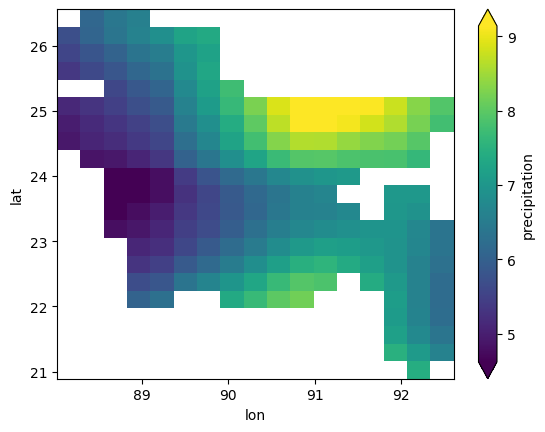

In [23]:
ds_mean.precipitation.plot(
    x = 'lon',
    y = 'lat',
    robust = True
)

In [24]:
!pip install xeofs
import xeofs as xf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.9/133.9 kB 3.9 MB/s eta 0:00:00


In [25]:
pca = xf.single.EOF(n_modes = 10)

In [26]:
pca.fit(ds, dim = 'time')

In [27]:
comp = pca.components()

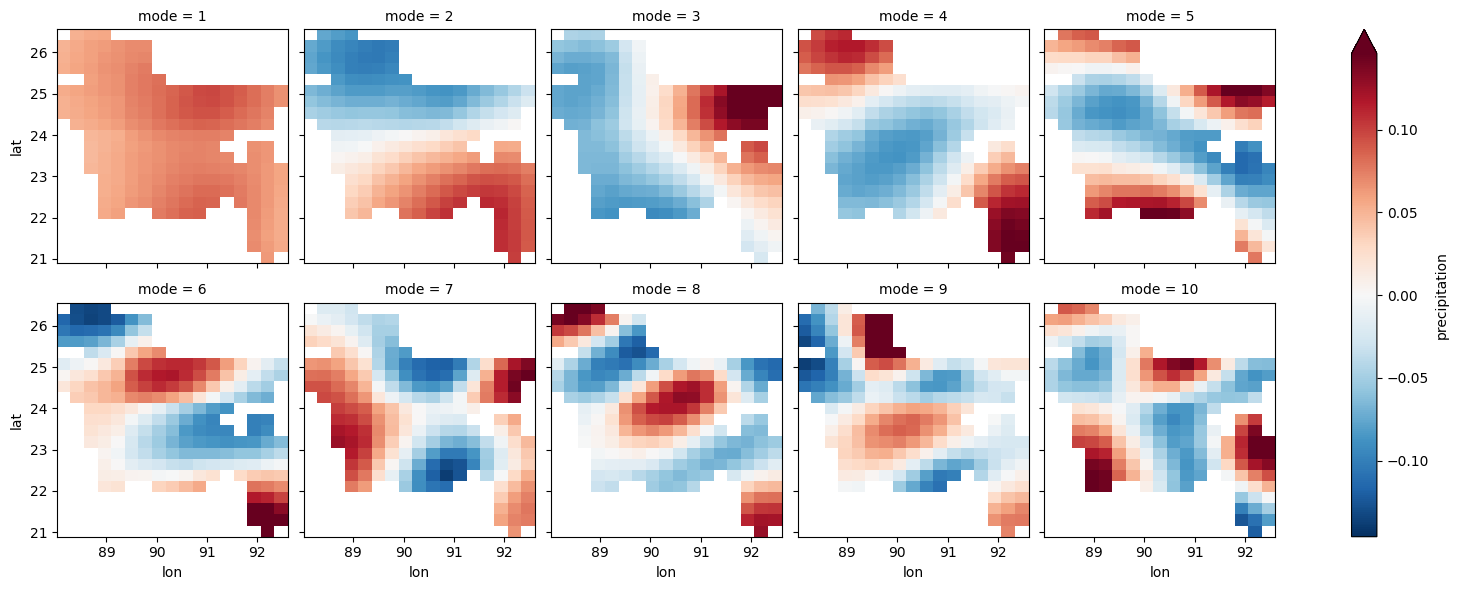

In [28]:
comp.precipitation.plot(
    x = 'lon',
    y = 'lat',
    robust = True,
    col = 'mode',
    col_wrap = 5
)